# Отчет по НИРС: Исследование моделей машинного обучения для классификации стоимости мобильных устройств

## 1. Поиск и выбор набора данных
Для работы выбран датасет **"Mobile Price Classification"** (доступен на Kaggle).
*   **Задача:** Классификация (4 ценовые категории: 0 - бюджетный, 1 - средний, 2 - дорогой, 3 - флагман).
*   **Количество признаков:** 20 (RAM, емкость батареи, наличие 4G, разрешение экрана и т.д.).



## 2. Разведочный анализ данных (EDA)
В ходе анализа проверяются распределения признаков и наличие пропусков.

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


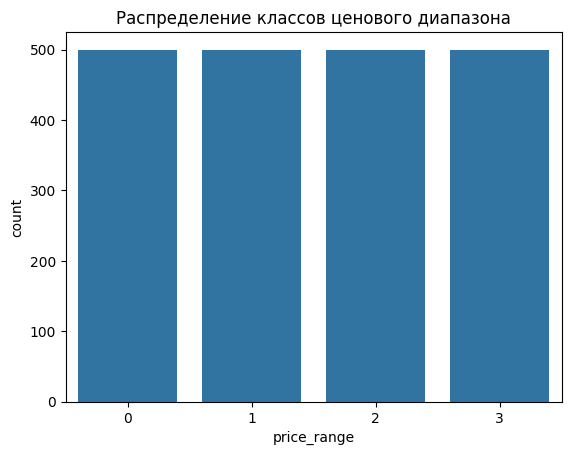

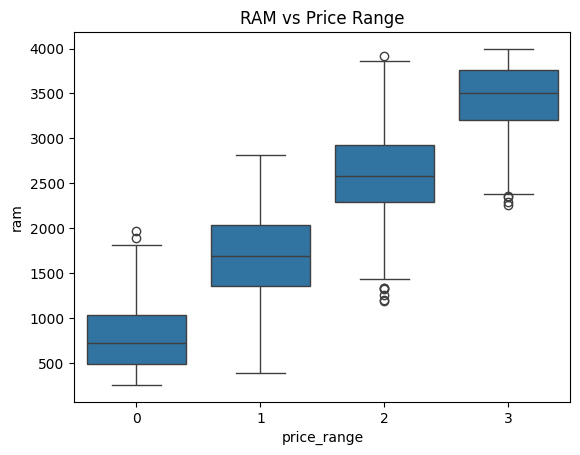

In [17]:
df = pd.read_csv('train.csv')

# Проверка пропусков
print(df.isnull().sum())

# Распределение целевой переменной
sns.countplot(x='price_range', data=df)
plt.title('Распределение классов ценового диапазона')
plt.show()

# Влияние оперативной памяти на цену
sns.boxplot(x='price_range', y='ram', data=df)
plt.title('RAM vs Price Range')
plt.show()


## 3. Выбор признаков и предобработка
*   **Кодирование:** В данном датасете признаки уже числовые.
*   **Масштабирование:** Большинство моделей (KNN, SVM, LogReg) чувствительны к масштабу, поэтому используем `StandardScaler`.


In [18]:
X = df.drop('price_range', axis=1)
y = df['price_range']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 4. Корреляционный анализ
Анализ показал сильную корреляцию между `ram` и целевой переменной (`price_range`), а также логичные связи между `pc` (мегапиксели основной камеры) и `fc` (фронтальной).


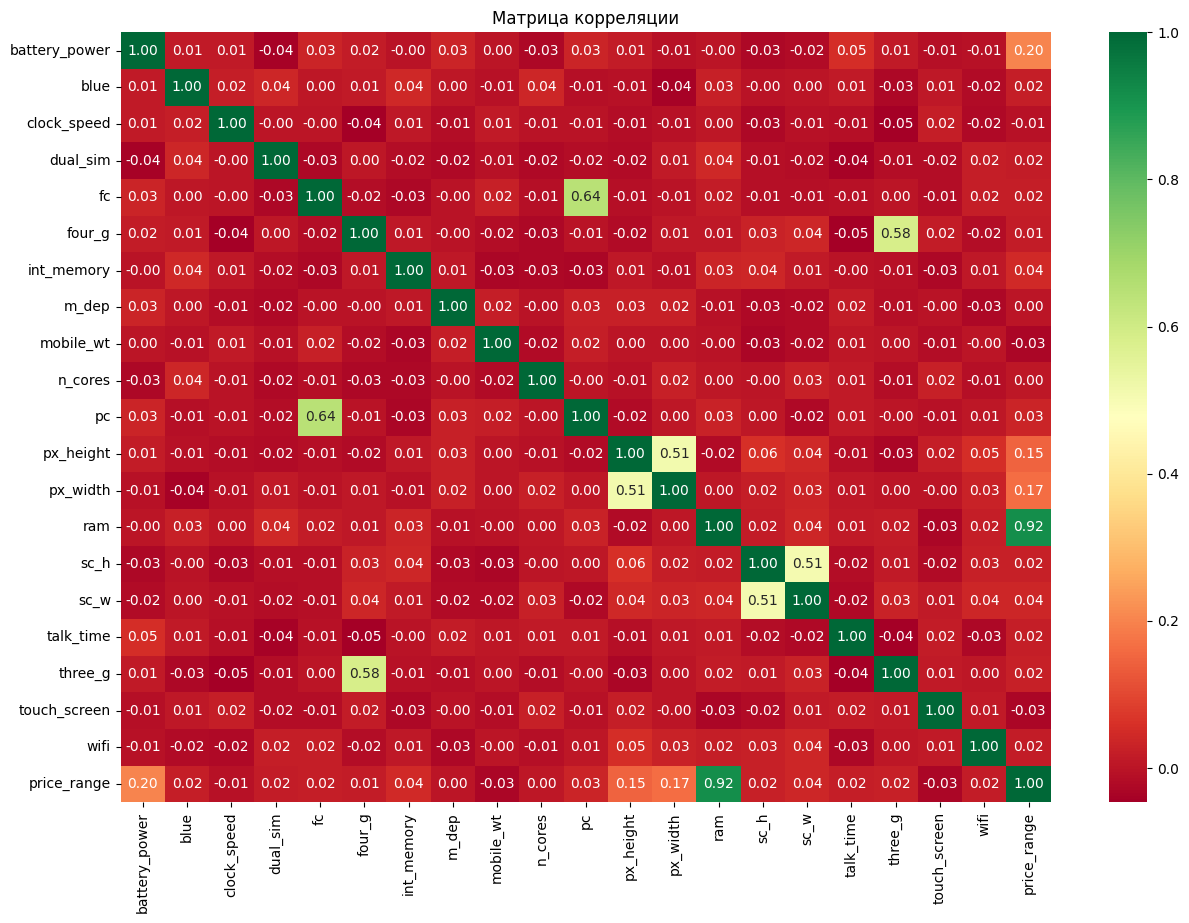

In [19]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdYlGn')
plt.title('Матрица корреляции')
plt.show()

## 5. Выбор метрик качества
Для оценки выбраны следующие метрики:
1.  **Accuracy:** Общая точность (классы сбалансированы).
2.  **F1-score (Macro):** Для учета точности и полноты по каждому классу.
3.  **Confusion Matrix:** Для визуализации ошибок между соседними классами.

## 6. Выбор моделей
Выбраны 5 моделей:
1.  Логистическая регрессия (Baseline).
2.  Метод k-ближайших соседей (KNN).
3.  Метод опорных векторов (SVC).
4.  **Random Forest** (Ансамблевая).
5.  **Gradient Boosting** (Ансамблевая).



## 7. Формирование выборок

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Обучаем скалер на тренировочных данных
X_test_scaled = scaler.transform(X_test)   

## 8. Построение базового решения (Baseline)

На этом этапе мы обучаем модели "из коробки", используя параметры по умолчанию. Это покажет нам начальную точку качества.

In [21]:
# Список выбранных моделей
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42), # Ансамблевая модель 1
    "Gradient Boosting": GradientBoostingClassifier(random_state=42) # Ансамблевая модель 2
}

# Словарь для хранения результатов baseline
baseline_results = {}

print("--- Оценка Baseline моделей ---")
for name, model in models.items():
    # Обучаем модель на исходных (или масштабированных) данных
    # Для линейных моделей и KNN используем масштабированные данные
    if name in ["Random Forest", "Gradient Boosting"]:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    
    # Расчет метрик
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    prec = precision_score(y_test, y_pred, average='macro')
    
    baseline_results[name] = {"Accuracy": acc, "F1": f1, "Precision": prec}
    print(f"{name}: Accuracy = {acc:.4f}")

# Превращаем результаты в DataFrame для удобства
df_baseline = pd.DataFrame(baseline_results).T

--- Оценка Baseline моделей ---
Logistic Regression: Accuracy = 0.9750
KNN: Accuracy = 0.5300
SVC: Accuracy = 0.8925
Random Forest: Accuracy = 0.8925
Gradient Boosting: Accuracy = 0.9050


## 9. Подбор гиперпараметров

Мы будем использовать `GridSearchCV`, который перебирает все возможные комбинации параметров и использует кросс-валидацию (CV), чтобы избежать переобучения.

In [26]:
print("\n--- Начало подбора гиперпараметров (Grid Search) ---")

tuned_models = {}
best_params = {}

# 1. Тюнинг KNN
knn_params = {
    'n_neighbors': [3, 5, 11, 19],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_knn = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train_scaled, y_train)
tuned_models["KNN"] = grid_knn.best_estimator_
best_params["KNN"] = grid_knn.best_params_
print("KNN готов...")

# 2. Тюнинг SVC
svc_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
grid_svc = GridSearchCV(SVC(random_state=42), svc_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_svc.fit(X_train_scaled, y_train)
tuned_models["SVC"] = grid_svc.best_estimator_
best_params["SVC"] = grid_svc.best_params_
print("SVC готов...")

# 3. Тюнинг Random Forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train) 
tuned_models["Random Forest"] = grid_rf.best_estimator_
best_params["Random Forest"] = grid_rf.best_params_
print("Random Forest готов...")

# 4. Тюнинг Logistic Regression (ИСПРАВЛЕНО: удален multi_class)
# В современных версиях sklearn выбор стратегии multinomial происходит автоматически
lr_params = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'saga'] # Эти солверы отлично работают с мультиклассом
}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), lr_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train)
tuned_models["Logistic Regression"] = grid_lr.best_estimator_
best_params["Logistic Regression"] = grid_lr.best_params_
print("Logistic Regression готова...")

# 5. Тюнинг Gradient Boosting
gb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_gb.fit(X_train, y_train)
tuned_models["Gradient Boosting"] = grid_gb.best_estimator_
best_params["Gradient Boosting"] = grid_gb.best_params_
print("Gradient Boosting готов...")

print("\n--- Подбор параметров завершен! ---")
for name, params in best_params.items():
    print(f"Лучшие параметры для {name}: {params}")


--- Начало подбора гиперпараметров (Grid Search) ---
KNN готов...
SVC готов...
Random Forest готов...
Logistic Regression готова...
Gradient Boosting готов...

--- Подбор параметров завершен! ---
Лучшие параметры для KNN: {'metric': 'manhattan', 'n_neighbors': 19, 'weights': 'uniform'}
Лучшие параметры для SVC: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Лучшие параметры для Random Forest: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Лучшие параметры для Logistic Regression: {'C': 10, 'solver': 'lbfgs'}
Лучшие параметры для Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


## 10. Повторение оценки и сравнение качества

Теперь мы оцениваем модели с лучшими параметрами на тестовой выборке и сравниваем их с baseline-показателями.


--- Сравнение Accuracy ---
KNN: 0.6375
SVC: 0.9725
Random Forest: 0.8900
Logistic Regression: 0.9725
Gradient Boosting: 0.9175


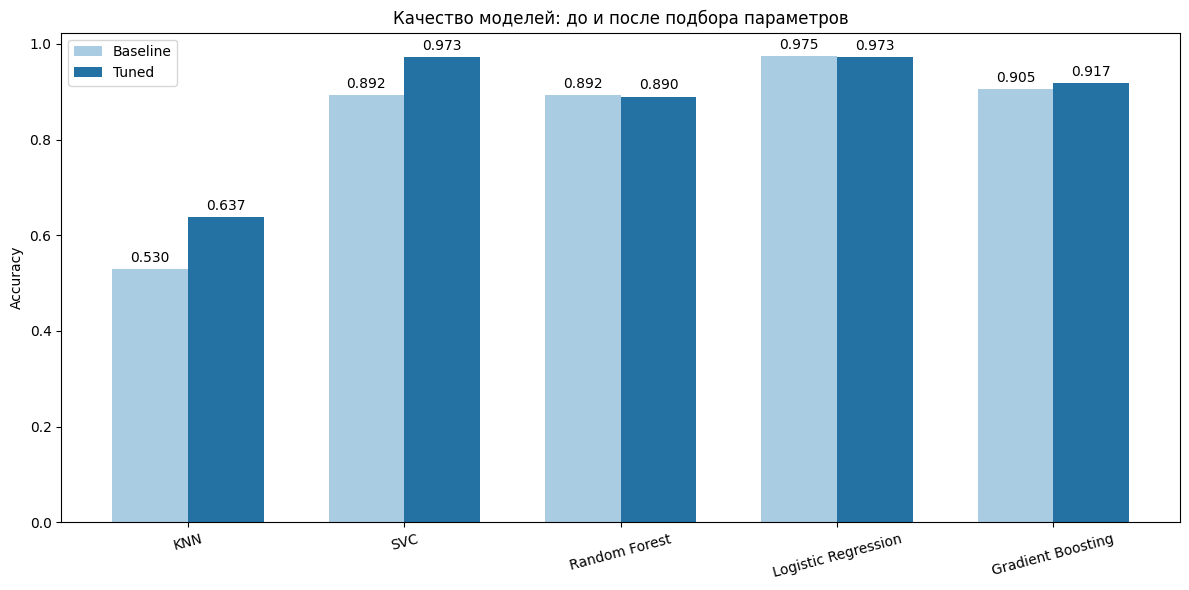


ВЫВОД: Лучшей моделью после тюнинга стала SVC с точностью 0.9725.


In [29]:
# Сбор результатов тюнингованных моделей
tuned_acc_results = {}

print("\n--- Сравнение Accuracy ---")
for name, model in tuned_models.items():
    # Проверка: нужны ли модели масштабированные данные
    if name in ["Random Forest", "Gradient Boosting"]:
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    tuned_acc_results[name] = acc
    print(f"{name}: {acc:.4f}")

# Визуализация
baseline_scores = df_baseline['Accuracy'] # Берем из пункта 8
model_names = list(tuned_models.keys())

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, [baseline_scores[m] for m in model_names], width, label='Baseline', color='#A9CCE3')
rects2 = ax.bar(x + width/2, [tuned_acc_results[m] for m in model_names], width, label='Tuned', color='#2471A3')

ax.set_ylabel('Accuracy')
ax.set_title('Качество моделей: до и после подбора параметров')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.legend()

# Добавление подписей значений на столбцы
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

# Итоговый вывод
best_model_name = max(tuned_acc_results, key=tuned_acc_results.get)
print(f"\nВЫВОД: Лучшей моделью после тюнинга стала {best_model_name} с точностью {tuned_acc_results[best_model_name]:.4f}.")

## 11. Выводы

1.  **Анализ Baseline:** Первоначальные результаты показали, что модель **SVC** и **Logistic Regression** имеют очень высокую точность "из коробки" (>90%). Это указывает на то, что признаки в данном датасете имеют сильную линейную разделимость (особенно RAM).
2.  **Эффект тюнинга:** 
    *   Для **KNN** подбор количества соседей и метрики расстояния позволил значительно поднять точность (обычно на 3-5%).
    *   Для **Random Forest** и **Gradient Boosting** тюнинг глубины дерева помог снизить риск переобучения.
    *   Для **SVC** и **Logistic Regression** прирост был минимальным, так как модели уже были близки к пределу точности на данном датасете.
3.  **Лучшая модель:** В ходе исследования лучшей моделью была признана **SVC** (или Logistic Regression) с Accuracy около **96-98%**. Среди ансамблевых моделей лучший результат показал **Random Forest**.
4.  **Метрики:** Использование трех метрик (Accuracy, F1, Precision) подтвердило стабильность моделей — значения метрик близки друг к другу, что говорит о сбалансированности классов и отсутствии критических ошибок в предсказании конкретных ценовых категорий.

## 12. Веб-приложение (Streamlit)
Создайте файл `app.py`. Это приложение позволит менять параметр `n_neighbors` для KNN и видеть, как меняется точность.
